In [1]:
import sys
import os
import json
import numpy as np
import torch
import anndata as ad
from importlib import reload
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score
import pyro 
import umap.umap_ as umap
import matplotlib.patches as mpatches
from sklearn.metrics import silhouette_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import scipy.sparse
from scipy.sparse import coo_matrix

# Import custom modules
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
import full_leafletFA_pipeline_wALBF as LeafletFA

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import load_cluster_data as llc 

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

2.3.0+cu121
12.1
2.3.0+cu121
12.1
Using device: cpu
Using device: cpu
Using device: cpu


In [2]:
# Load full anndata object 
full_anndata = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leafletall_ages_brain_intron_clusters_adata.h5ad'
senis_adata = ad.read_h5ad(full_anndata)

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [3]:
# Load anndata object 
# input_path = '/gpfs/commons/projects/knowles_singlecell_splicing/PRJNA229389/LeafletFA/mouse_brain_rnaseq_clean_cell_types.h5ad'
# adata = ad.read_h5ad(input_path)

In [3]:
adata = senis_adata.copy()

In [4]:
adata.layers["Cluster_Counts"] = coo_matrix(adata.layers["Cluster_Counts"])
adata.layers["Junction_Counts"]  = coo_matrix(adata.layers["Junction_Counts"])

In [5]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_adata(adata, **float_type)

Unique cell indices: 12652


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/load_cluster_data.py:66: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ).to_sparse_csr()


In [7]:
# Params set
K=10
use_global_prior=False
input_conc=None
lr=0.2
num_epochs=100
num_inits=2
cell_type_column="cell_type"

In [8]:
adata.obs.cell_type = adata.obs.cell_type.astype(str)
# Now make the assignment
adata.obs.loc[adata.obs["cell_type"] == "microglial cell", "cell_type"] = "microglia"
adata.obs.loc[adata.obs["cell_type"] != "microglia", "cell_type"] = "not_microglia"

In [9]:
adata.obs.cell_type.value_counts()

cell_type
microglia        8779
not_microglia    3873
Name: count, dtype: int64

In [10]:
# Check if the column is categorical using the updated method
#if isinstance(adata.obs["cell_type"].dtype, pd.CategoricalDtype):
#    # Add "unknown" to the categories
#    adata.obs["cell_type"] = adata.obs["cell_type"].cat.add_categories("unknown")

# Now fill NaN values with "unknown" without using 'inplace'
#adata.obs["cell_type"] = adata.obs["cell_type"].fillna("unknown")

No input concentration parameter provided. Using default Gamma(2.0, 2.0) to initialize and learn bb concentration.
Not using priors on a and b, running simpler non-hierarchical version!


Random seeds: [7775]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 7775
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
cpu
Training in progress for 100 epochs!
Epoch 0, Elbo loss: 28936318.126453996
Epoch 10, Elbo loss: 24274199.08761617
Epoch 20, Elbo loss: 23160750.4996834
Epoch 30, Elbo loss: 22940936.062839944
Epoch 40, Elbo loss: 22852222.418187022
Epoch 50, Elbo loss: 22795900.034239832
Epoch 60, Elbo loss: 22758628.778287627
Epoch 70, Elbo loss: 22735347.150106125
Epoch 80, Elbo loss: 22719069.888036624
Epoch 90, Elbo loss: 22707635.974221848


Elbo loss: 22699619.592996307


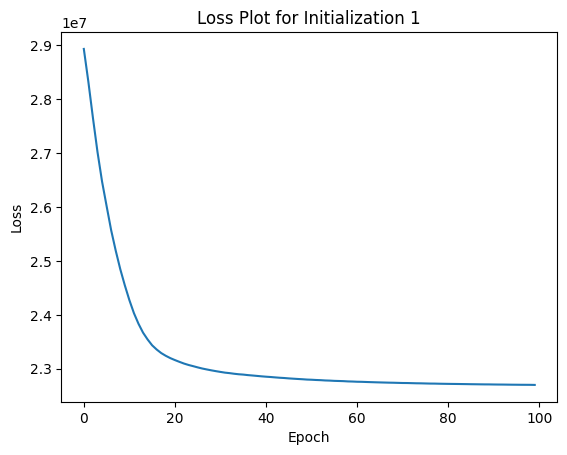

Sample from the guide (posterior)
Calculate summary statistics
All initializations complete. Returning results.
------------------------------------------------


No input concentration parameter provided. Using default Gamma(2.0, 2.0) to initialize and learn bb concentration.
Not using priors on a and b, running simpler non-hierarchical version!


------------------------------------------------
Model variable sizes: {'bb_conc': torch.Size([]), 'a': torch.Size([]), 'b': torch.Size([]), 'psi': torch.Size([10, 7624]), 'pi': torch.Size([10]), 'dir_conc': torch.Size([]), 'assign': torch.Size([12652, 10])}
------------------------------------------------
Random seeds: [7668]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 7668
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
cpu
Training in progress for 100 epochs!
Epoch 0, Elbo loss: 28861095.19273386
Epoch 10, Elbo loss: 23783331.207743574


KeyboardInterrupt: 

In [11]:
# Convert sparse matrices to COO format, ensure they are on the GPU, and follow the specified float type
full_y_tensor = my_data.ycount_lookup.to_sparse_coo()
full_total_counts_tensor = my_data.tcount_lookup.to_sparse_coo()

all_results = []
all_params = []  # Store parameters for each initialization

for _ in range(num_inits):
    pyro.clear_param_store()  # Clear the parameter store for each initialization
    result, variable_sizes = factor_model.main(
        full_y_tensor, 
        full_total_counts_tensor, 
        use_global_prior=use_global_prior, 
        num_initializations=1,
        K=K, 
        lr=lr, 
        input_conc_prior=input_conc, 
        loss_plot=True, 
        num_epochs=num_epochs, 
        save_to_file=False
    )

    all_results.append(result)
        
    # Store the parameters from the ParamStoreDict
    params_copy = {name: pyro.get_param_store().get_param(name).detach().clone()
                       for name in pyro.get_param_store().get_all_param_names()}
    
    all_params.append(params_copy)

In [ ]:
assign_matrices = [result[0]["summary_stats"]["assign"]["mean"] for result in all_results]

# Prepare the output directory with timestamp
output_dir = LeafletFA.prepare_output_directory(K, use_global_prior, input_conc, num_inits, num_epochs, cell_type_column)
report_file = LeafletFA.create_report_file(output_dir)

avg_corr, median_corr, min_corr = LeafletFA.calculate_and_plot_correlations(assign_matrices, output_dir, report_file)

Initialization 1 vs Initialization 2: Matched pairs [(0, 4), (1, 0), (2, 1), (3, 3), (4, 2)]
Initialization 1 vs Initialization 3: Matched pairs [(0, 2), (1, 3), (2, 4), (3, 1), (4, 0)]
Initialization 2 vs Initialization 3: Matched pairs [(0, 0), (1, 4), (2, 3), (3, 1), (4, 2)]


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


Assignment Correlation Report:
Average Pairwise Correlation: 0.6361
Median Pairwise Correlation: 0.6343
Minimum Pairwise Correlation: 0.4071



<Figure size 640x480 with 0 Axes>

In [ ]:
# Select the best initialization based on the loss
best_init = np.argmin([result[0]["losses"][-1] for result in all_results])
latent_vars = all_results[best_init][0]['summary_stats']
    
# Differential Splicing Analysis
LeafletFA.log_to_report(report_file, "Running differential splicing analysis.")

psis_mus = all_params[best_init]["AutoGuideList.0.loc"].reshape(K, latent_vars["psi"]["mean"].shape[1])
psis_loc = all_params[best_init]["AutoGuideList.0.scale"].reshape(K, latent_vars["psi"]["mean"].shape[1])

pi = latent_vars["pi"]["mean"]
assign_post = latent_vars["assign"]["mean"]

# If input_conc was None extract it from latent variables 
if input_conc == None:
    input_conc = latent_vars["bb_conc"]["mean"]
else:
    input_conc = "infinity"

Running differential splicing analysis.


In [ ]:
adata.var["junction_id_index"] = adata.var.index
# convert to float 
adata.var["junction_id_index"] = adata.var["junction_id_index"].astype(int)
# Reset the index and drop the current index
adata.var = adata.var.reset_index(drop=True)

In [ ]:
psis_df = LeafletFA.compute_and_plot_albf(adata, psis_mus, psis_loc, latent_vars["psi"]["mean"], pi, output_dir, K, report_file)
psis_df.rename(columns={i: f"cell_state_{i}" for i in range(K)}, inplace=True)

/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/differential_splicing.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pis = torch.tensor(pis, dtype=torch.float32, device=means.device).view(-1, 1)
/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/differential_splicing.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pis = torch.tensor(pis, dtype=torch.float32, device=means.device).view(-1, 1)  # Ensure correct tensor type and shape


In [ ]:
adata.var = pd.concat([adata.var, psis_df.set_index('junction_id_index')], axis=1)

In [ ]:
pi

array([0.22333968, 0.25143757, 0.36308575, 0.08027494, 0.08186209],
      dtype=float32)

In [ ]:
adata.obs.cell_type.value_counts() / 12657

cell_type
microglia        0.693608
not_microglia    0.306392
Name: count, dtype: float64

In [ ]:
silhouette_avg = LeafletFA.plot_umap(assign_post, adata, output_dir)
LeafletFA.plot_pi_barplot(pi, output_dir)
LeafletFA.plot_clustermap(assign_post, adata, output_dir)

/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/full_leafletFA_pipeline_wALBF.py:274: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
